# 🔄 使用 GitHub 模型的基本代理工作流 (Python)

## 📋 工作流编排教程

本笔记本介绍了 Microsoft Agent Framework 强大的 **Workflow Builder** 功能。学习如何创建复杂的多步骤代理工作流，这些工作流可以处理复杂的业务流程并无缝协调多个 AI 操作。

## 🎯 学习目标

### 🏗️ **工作流架构**
- **Workflow Builder**：设计和编排复杂的多步骤流程
- **事件驱动执行**：处理工作流事件和状态转换
- **可视化工作流设计**：创建和可视化工作流结构
- **GitHub 模型集成**：在工作流上下文中利用 AI 模型

### 🔄 **流程编排**
- **顺序操作**：以逻辑顺序链接多个代理任务
- **条件逻辑**：实现决策点和分支工作流
- **错误处理**：强大的错误恢复和工作流弹性
- **状态管理**：跟踪和管理工作流执行状态

### 📊 **企业工作流模式**
- **业务流程自动化**：自动化复杂的组织工作流
- **多代理协调**：协调多个专业代理
- **可扩展执行**：设计企业规模操作的工作流
- **监控与可观察性**：跟踪工作流性能和结果

## ⚙️ 前提条件和设置

### 📦 **必需依赖项**

安装具有工作流功能的 Agent Framework：

```bash
pip install agent-framework-core -U
```

### 🔑 **GitHub 模型配置**

**环境设置 (.env 文件)**：
```env
GITHUB_TOKEN=your_github_personal_access_token
GITHUB_ENDPOINT=https://models.inference.ai.azure.com
GITHUB_MODEL_ID=gpt-4o-mini
```

### 🏢 **企业用例**

**业务流程示例**：
- **客户入职**：多步骤验证和设置工作流
- **内容管道**：自动化内容创建、审核和发布
- **数据处理**：具有 AI 驱动转换的 ETL 工作流
- **质量保证**：自动化测试和验证流程

**工作流优势**：
- 🎯 **可靠性**：具有错误恢复的确定性执行
- 📈 **可扩展性**：处理高容量流程自动化
- 🔍 **可观察性**：完整的审计跟踪和监控
- 🔧 **可维护性**：可视化设计和模块化组件

## 🎨 工作流设计模式

### 基本工作流结构
```mermaid
graph TD
    A[开始] --> B[代理任务 1]
    B --> C{决策点}
    C -->|成功| D[代理任务 2]
    C -->|失败| E[错误处理]
    D --> F[结束]
    E --> F
```

**关键组件**：
- **WorkflowBuilder**：主要编排引擎
- **WorkflowEvent**：事件处理和通信
- **WorkflowViz**：可视化工作流表示和调试

让我们构建您的第一个智能工作流！🚀

In [ ]:
#! pip install agent-framework-core -U

In [1]:
# 🔄 导入工作流和代理框架组件
# 用于构建复杂代理工作流的核心组件

from agent_framework.openai import OpenAIChatClient    # 🤖 GitHub 模型客户端集成
from agent_framework import WorkflowBuilder, WorkflowEvent, WorkflowViz  # 🏗️ 工作流编排工具

In [2]:
# 📦 导入环境和系统实用程序
# 用于配置和环境管理的必要库

import os                      # 🔧 环境变量访问
from dotenv import load_dotenv # 📁 安全配置加载

In [3]:
# 🔧 初始化环境配置
# 从 .env 文件加载 GitHub 模型 API 凭证
load_dotenv()

True

In [4]:
# 🔗 初始化 GitHub 模型聊天客户端用于工作流操作
# 创建将为工作流中的代理提供动力的 AI 客户端
chat_client = OpenAIChatClient(
    base_url=os.environ.get("API_URL"),      # 🌐 GitHub 模型 API 端点
    api_key=os.environ.get("API_KEY"),       # 🔑 认证令牌
    model_id=os.environ.get("MODEL_FREE_8B") # 🎯 选定的 AI 模型
)

In [5]:
REVIEWER_NAME = "Concierge"
REVIEWER_INSTRUCTIONS = """
    你是一位酒店礼宾员，对为旅行者提供最本地化和真实的体验有自己的见解。
    目标是确定前台旅行顾问是否为旅行者推荐了最佳的非旅游景点体验。
    如果是，请说明已批准。
    如果不是，请提供如何改进推荐的见解，不要使用具体例子。
    """

In [6]:
FRONTDESK_NAME = "FrontDesk"
FRONTDESK_INSTRUCTIONS = """
    你是一位拥有十年经验的前台旅行顾问，以简洁著称，因为你要处理许多客户。
    目标是为旅行者提供最佳的活动和游览地点。
    每次响应只提供一个推荐。
    你专注于手头的目标。
    不要浪费时间闲聊。
    改进想法时考虑建议。
    """

In [8]:
reviewer_agent   = chat_client.as_agent(
        instructions=(
           REVIEWER_INSTRUCTIONS
        ),
        name=REVIEWER_NAME,
    )

front_desk_agent = chat_client.as_agent(
        instructions=(
            FRONTDESK_INSTRUCTIONS
        ),
        name=FRONTDESK_NAME,
    )

In [9]:
workflow = WorkflowBuilder().set_start_executor(front_desk_agent).add_edge(front_desk_agent, reviewer_agent).build()

In [12]:

print("生成工作流可视化...")
viz = WorkflowViz(workflow)
# 打印出 mermaid 字符串。
print("Mermaid 字符串: \n=======")
print(viz.to_mermaid())
print("=======")
# 打印出 DiGraph 字符串。
print("DiGraph 字符串: \n=======")
print(viz.to_digraph())
print("=======")
svg_file = viz.export(format="svg")
print(f"SVG 文件保存到: {svg_file}")

生成工作流可视化...
Mermaid 字符串: 
flowchart TD
  FrontDesk["FrontDesk (Start)"];
  Concierge["Concierge"];
  FrontDesk --> Concierge;
DiGraph 字符串: 
digraph Workflow {
  rankdir=TD;
  node [shape=box, style=filled, fillcolor=lightblue];
  edge [color=black, arrowhead=vee];

  "FrontDesk" [fillcolor=lightgreen, label="FrontDesk\n(Start)"];
  "Concierge" [label="Concierge"];
  "FrontDesk" -> "Concierge";
}
SVG 文件保存到: /tmp/tmpltgnwvdo.svg


In [13]:
class DatabaseEvent(WorkflowEvent): ...

尝试显示 SVG 文件: /tmp/tmpltgnwvdo.svg


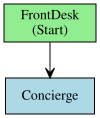

In [14]:
# 在笔记本中内联显示导出的工作流 SVG

from IPython.display import SVG, display, HTML
import os

print(f"尝试显示 SVG 文件: {svg_file}")

if svg_file and os.path.exists(svg_file):
    try:
        # 首选：直接 SVG 渲染
        display(SVG(filename=svg_file))
    except Exception as e:
        print(f"⚠️ 直接 SVG 渲染失败: {e}。回退到原始 HTML。")
        try:
            with open(svg_file, "r", encoding="utf-8") as f:
                svg_text = f.read()
            display(HTML(svg_text))
        except Exception as inner:
            print(f"❌ 回退 HTML 渲染也失败: {inner}")
else:
    print("❌ SVG 文件未找到。确保 viz.export(format='svg') 成功运行。")


In [15]:
result =''
async for event in workflow.run_stream('我想去巴黎。'):
    if isinstance(event, DatabaseEvent):
        print(f"{event}")
    if isinstance(event, WorkflowEvent):
        result += str(event.data)
        # print(f"工作流输出: {event.data}")

In [16]:
result.replace("None", "")

"我想去巴黎。[AgentExecutorResponse(executor_id='FrontDesk', agent_response=<agent_framework._types.AgentResponse object at 0x74a0a576e090>, full_conversation=[<agent_framework._types.ChatMessage object at 0x74a0a5823080>, <agent_framework._types.ChatMessage object at 0x74a0a58d2cf0>])]AgentExecutorResponse(executor_id='FrontDesk', agent_response=<agent_framework._types.AgentResponse object at 0x74a0a4584950>, full_conversation=[<agent_framework._types.ChatMessage object at 0x74a0a57799d0>, <agent_framework._types.ChatMessage object at 0x74a0a4584b00>])[AgentExecutorResponse(executor_id='Concierge', agent_response=<agent_framework._types.AgentResponse object at 0x74a0a492d610>, full_conversation=[<agent_framework._types.ChatMessage object at 0x74a0a5823080>, <agent_framework._types.ChatMessage object at 0x74a0a58d2cf0>, <agent_framework._types.ChatMessage object at 0x74a0a57781a0>])]"